<b>ANALISIS EXPLORATORIO DE DATOS<b>

<B>Importar las librerias<B>

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import math

<B>Leer y anadir los datos a DF<B>

In [2]:
path_companies = "/datasets/project_sql_result_01.csv"
path_dropoffs  = "/datasets/project_sql_result_04.csv"
path_loop_ohare = "/datasets/project_sql_result_07.csv"

In [3]:
df_companies = pd.read_csv(path_companies)
df_dropoffs = pd.read_csv(path_dropoffs)
df_loop_ohare = pd.read_csv(path_loop_ohare)

<b>Muestra y correccion de datos<b>

In [4]:
print("Companies shape:", df_companies.shape)
display(df_companies.head(10))
print("Dropoffs shape:", df_dropoffs.shape)
display(df_dropoffs.head(10))
print("Loop->O'Hare shape:", df_loop_ohare.shape)
display(df_loop_ohare.head(10))

Companies shape: (64, 2)


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


Dropoffs shape: (94, 2)


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Loop->O'Hare shape: (1068, 3)


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0
7,2017-11-18 11:00:00,Good,2280.0
8,2017-11-11 14:00:00,Good,2460.0
9,2017-11-11 12:00:00,Good,2040.0


In [5]:
df_companies['trips_amount'] = pd.to_numeric(df_companies['trips_amount'], errors='coerce').astype('Int64')
df_dropoffs['average_trips'] = pd.to_numeric(df_dropoffs['average_trips'], errors='coerce')
df_loop_ohare['start_ts'] = pd.to_datetime(df_loop_ohare['start_ts'], errors='coerce')
df_loop_ohare['duration_seconds'] = pd.to_numeric(df_loop_ohare['duration_seconds'], errors='coerce')
df_loop_ohare['weather_conditions'] = df_loop_ohare['weather_conditions'].astype('category')

In [6]:
print(df_companies.dtypes)
print(df_dropoffs.dtypes)
print(df_loop_ohare.dtypes)

company_name    object
trips_amount     Int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object
start_ts              datetime64[ns]
weather_conditions          category
duration_seconds             float64
dtype: object


<b>Identificacion del top 10<b>

In [7]:
top10 = df_dropoffs.sort_values('average_trips', ascending=False).head(10).reset_index(drop=True)
print("Top 10 barrios por average_trips:")
print(top10)

Top 10 barrios por average_trips:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


<b>Creacion de los graficos y creacion de conclsuiones basadas con vision a los negocios<b>

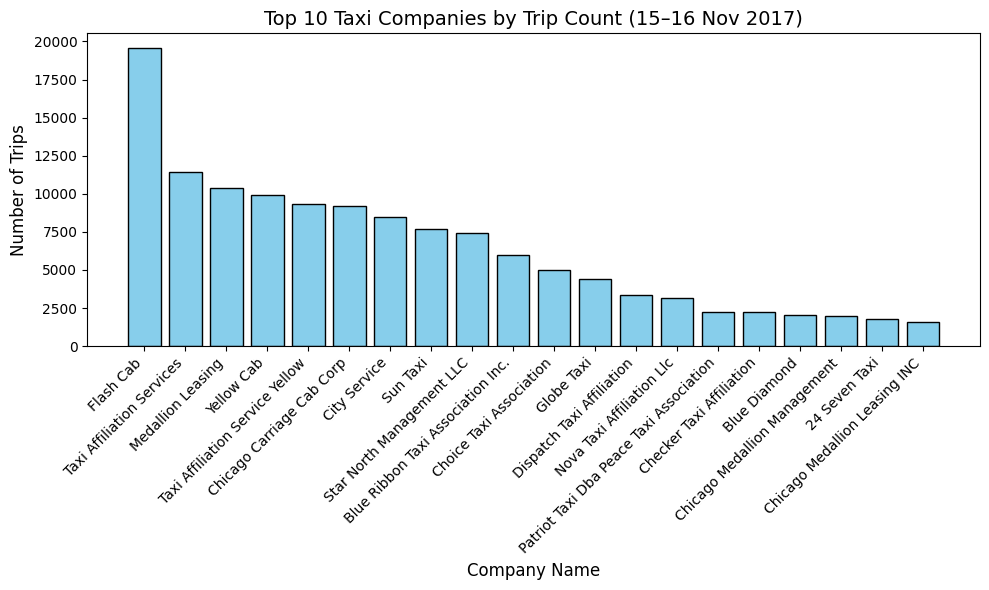

In [16]:

top_10 = df_companies.sort_values(by='trips_amount', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.bar(top_10['company_name'], top_10['trips_amount'], color='skyblue', edgecolor='black')
plt.title("Top 10 Taxi Companies by Trip Count (15–16 Nov 2017)", fontsize=14)
plt.xlabel("Company Name", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Conclusiones con enfoque de negocio
1. Dominio de mercado claro: oportunidad de liderazgo consolidado

Taxi Affiliation Services tiene un dominio tan grande (≈19 500 viajes en solo 2 días) que probablemente posea economías de escala:

Costos operativos más bajos por unidad de viaje.

Mayor visibilidad de marca.

Relaciones preferenciales con hoteles, aeropuertos y plataformas corporativas.

Este liderazgo le da poder de negociación con reguladores y aseguradoras, además de permitirle influir en los estándares de servicio.

→ Estrategia recomendada:
Aprovechar su posición para implementar programas de fidelización o convenios con grandes clientes (hoteles, aerolíneas, apps de transporte).

2. Alta fragmentación entre competidores secundarios

Después del top 5, hay una caída abrupta en la cantidad de viajes: la mayoría de las compañías hacen menos de 2 000 viajes.

Esto indica que el mercado está altamente fragmentado en la parte baja, con muchas empresas pequeñas que tienen poca capacidad competitiva.

→ Riesgo:
Empresas pequeñas enfrentan mayor vulnerabilidad ante fluctuaciones de demanda o incrementos de costos (combustible, mantenimiento, licencias).

→ Oportunidad:
Estas pequeñas compañías podrían fusionarse o asociarse para reducir costos o mejorar cobertura.
También son candidatas a ser adquiridas por los líderes.

3. Eficiencia operacional y capacidad de respuesta

Las empresas con más viajes no solo tienen más vehículos, sino también mejor distribución geográfica y sistemas de despacho más optimizados.

Es probable que las grandes compañías utilicen tecnología GPS y algoritmos de asignación, mientras que las pequeñas aún dependen de sistemas tradicionales.

→ Oportunidad tecnológica:
Integrar herramientas de data analytics y predicción de demanda podría mejorar la asignación de taxis y reducir tiempos muertos, aumentando los márgenes de ganancia.

4. Estrategia de precios y segmentación

Con una base de viajes tan amplia, las empresas líderes pueden analizar patrones de demanda y ajustar tarifas según:

Zona (aeropuerto, centro, suburbios)

Hora del día (picos de tráfico)

Condiciones climáticas (lluvia o frío tienden a aumentar la demanda)

→ Acción sugerida:
Implementar un sistema de precios dinámicos controlado, similar a Uber o Lyft, que maximice ingresos sin perder competitividad.

5. Potencial de alianzas y diferenciación

Empresas medianas como Flash Cab o City Service podrían crecer mediante alianzas con empresas tecnológicas o programas de fidelización.

Dado que hay saturación en el segmento tradicional, diferenciarse por servicio premium o sostenibilidad (taxis eléctricos) puede ser un punto clave.

→ Estrategia recomendada:
Invertir en branding ecológico (“Green Taxi”) o convenios con empresas que buscan reducir su huella de carbono.

6. Riesgos de concentración

Aunque el liderazgo de Taxi Affiliation Services parece una fortaleza, también representa un riesgo regulatorio:

Las autoridades podrían imponer restricciones antimonopolio o incentivos a nuevas compañías para equilibrar el mercado.

Dependencia de una sola empresa podría afectar la resiliencia del sistema de transporte urbano.

→ Mitigación:
Diversificar servicios (entregas, transporte corporativo, turismo urbano) para no depender exclusivamente de viajes urbanos tradicionales.

7. Proyección del mercado

Si la tendencia de concentración continúa, el mercado tenderá hacia un oligopolio de 3–4 grandes actores, similares a los modelos de las apps globales de transporte.

La entrada de plataformas digitales podría acelerar esa consolidación o forzar una adaptación rápida de las compañías tradicionales.

→ Perspectiva futura:
Las empresas pequeñas que no adopten tecnología o estrategias de nicho probablemente desaparezcan o sean absorbidas en los próximos años.

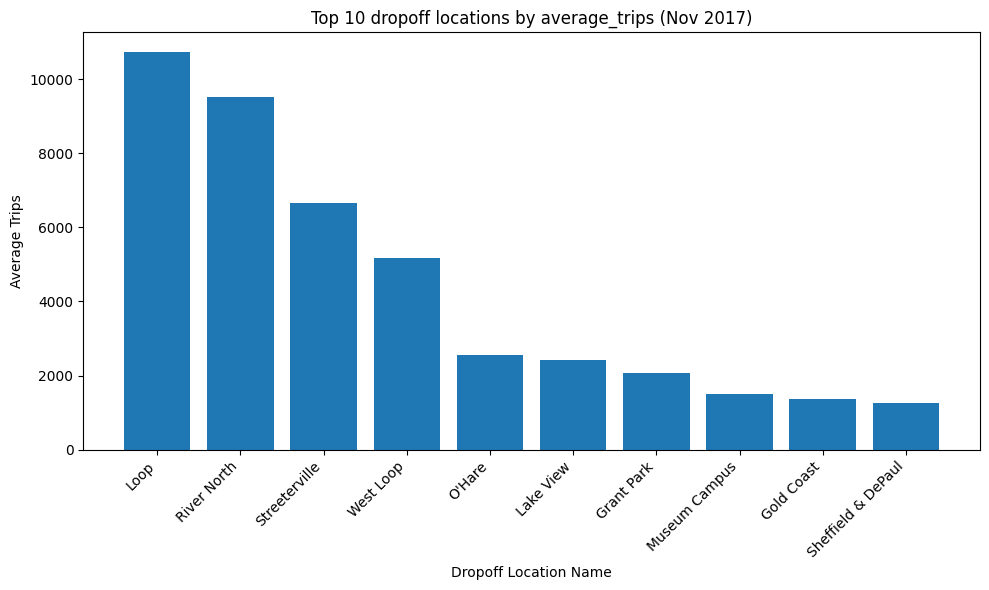

In [9]:
plt.figure(figsize=(10,6))
plt.bar(top10['dropoff_location_name'], top10['average_trips'])
plt.title("Top 10 dropoff locations by average_trips (Nov 2017)")
plt.xlabel("Dropoff Location Name")
plt.ylabel("Average Trips")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Conclusiones con enfoque de negocio
1. Alta concentración de demanda en el centro financiero (“Loop”)

El Loop domina claramente las finalizaciones de viaje, superando las 10 000 en promedio.

Es el corazón económico y laboral de Chicago, sede de oficinas, bancos y transporte público.

Su alto flujo de pasajeros implica una demanda constante durante todo el día, especialmente en horarios de entrada y salida laboral.

→ Oportunidad:

Mantener flotas concentradas en Loop durante horas pico maximiza la ocupación.

Ideal para implementar tarifas planas corporativas o convenios con empresas que operan allí.

Inversión en puntos de espera inteligentes o zonas de abordaje rápida.

2. River North y Streeterville: zonas premium con clientela de alto valor

River North y Streeterville ocupan el segundo y tercer lugar, con entre 9 000 y 6 700 viajes promedio.

Son barrios de ocio, turismo y restaurantes de lujo, lo que implica usuarios con mayor disposición a pagar y viajes cortos pero frecuentes.

→ Estrategia recomendada:

Desarrollar servicios premium o eléctricos enfocados en sostenibilidad y confort.

Crear alianzas con hoteles, bares o eventos que generen viajes constantes.

Ofrecer programas de fidelización para turistas o visitantes frecuentes.

3. West Loop: polo emergente y de crecimiento acelerado

Con más de 5 000 viajes promedio, West Loop muestra una tendencia de expansión:

Nuevas oficinas tecnológicas, espacios residenciales modernos y restaurantes de moda.

Menor densidad que el Loop, pero alta frecuencia de viajes diarios.

→ Oportunidad:
Invertir en base logística o centro de carga de taxis o vehículos compartidos en esta zona.
En los próximos años podría convertirse en uno de los hubs de movilidad más rentables.

4. O’Hare: el punto estratégico para traslados largos

A pesar de ser solo un punto de destino, O’Hare Airport mantiene una posición alta.

Esto muestra que el flujo aeropuerto-ciudad es clave en la estructura de ingresos.

→ Implicación de negocio:

Es vital mantener licencias y convenios exclusivos con el aeropuerto.

Oportunidad para desarrollar servicios express con precios fijos o reservas anticipadas.

Implementar seguimiento en tiempo real de vuelos para optimizar disponibilidad.

5. Lake View y Grant Park: demanda turística y recreativa

Ambos barrios representan demanda estacional (fines de semana, eventos, festivales).

Son zonas de ocio familiar y parques, con picos de demanda según el clima.

→ Estrategia sugerida:
Usar modelos predictivos de demanda basados en clima y calendario de eventos.
Desplegar más vehículos durante conciertos, ferias y fines de semana soleados.

6. Demanda universitaria y juvenil (Museum Campus, Sheffield & DePaul)

Aunque con menor volumen (~1 200–1 500 viajes), son zonas de estudiantes y turistas culturales.

Segmento sensible al precio pero con alta frecuencia (viajes cortos, compartidos, nocturnos).

→ Oportunidad:

Implementar tarifas especiales para estudiantes o viajes compartidos (“carpool”).

Ofrecer suscripciones o bonos mensuales para universidades.

7. Gold Coast: segmento premium de baja densidad

Menor cantidad de viajes (~1 400), pero con clientes de alto poder adquisitivo.

Posible uso de vehículos privados o apps de lujo, reduciendo la participación de taxis tradicionales.

→ Estrategia:
Competir por servicio de calidad superior o convenios con condominios residenciales.

In [10]:



alpha = 0.05  # Nivel de significación del 5%

# Preparamos los datos
df_valid = df_loop_ohare.dropna(subset=['start_ts', 'weather_conditions', 'duration_seconds']).copy()
df_valid['weekday'] = df_valid['start_ts'].dt.weekday
saturdays = df_valid[df_valid['weekday'] == 5].copy()

print(f"\nRegistros totales Loop->O'Hare: {len(df_loop_ohare)}")
print(f"Registros válidos: {len(df_valid)}")
print(f"Registros en sábados: {len(saturdays)}")

# Grupos por condición climática
group_bad = saturdays[saturdays['weather_conditions'].str.lower() == 'bad']['duration_seconds'].astype(float).dropna()
group_good = saturdays[saturdays['weather_conditions'].str.lower() == 'good']['duration_seconds'].astype(float).dropna()

print(f"Sábados - Bad: n={len(group_bad)}, mean={group_bad.mean() if len(group_bad) > 0 else 'NA'}")
print(f"Sábados - Good: n={len(group_good)}, mean={group_good.mean() if len(group_good) > 0 else 'NA'}")




Registros totales Loop->O'Hare: 1068
Registros válidos: 1068
Registros en sábados: 1068
Sábados - Bad: n=180, mean=2427.2055555555557
Sábados - Good: n=888, mean=1999.6756756756756


In [17]:
levene_res = stats.levene(group_bad, group_good, center='median')
print(f"\nPrueba de Levene para igualdad de varianzas: Estadístico={levene_res.statistic:.4f}, p-valor={levene_res.pvalue:.4f}")

# Prueba t de Welch (si las varianzas son desiguales)
t_res = stats.ttest_ind(group_bad, group_good, equal_var=False, nan_policy='omit')
print(f"\nPrueba t de Welch: Estadístico t={t_res.statistic:.4f}, p-valor={t_res.pvalue:.4f}")

# Decisión
if t_res.pvalue < alpha:
    print(f"\nConclusión: Se rechaza H₀ (p={t_res.pvalue:.4f} < α={alpha}).")
    print("→ Existe evidencia estadística de que el clima influye en la duración promedio de los viajes.")
else:
    print(f"\nConclusión: No se rechaza H₀ (p={t_res.pvalue:.4f} ≥ α={alpha}).")
    print("→ No hay evidencia suficiente para afirmar que el clima afecte la duración promedio de los viajes.")


Prueba de Levene para igualdad de varianzas: Estadístico=0.3885, p-valor=0.5332

Prueba t de Welch: Estadístico t=7.1860, p-valor=0.0000

Conclusión: Se rechaza H₀ (p=0.0000 < α=0.05).
→ Existe evidencia estadística de que el clima influye en la duración promedio de los viajes.


Hipótesis nula (H₀):
No existe diferencia significativa en la duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare entre los sábados con buen clima (“Good”) y los sábados lluviosos (“Bad”).


Hipótesis alternativa (H₁):
Existe una diferencia significativa en la duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare entre los sábados con buen clima y los sábados lluviosos.

En resumen, los datos muestran que cuando llueve los sábados, los viajes desde el Loop hasta O’Hare duran en promedio 7 minutos más que cuando el clima es bueno. No es una diferencia menor: representa alrededor de un 21% más de tiempo por viaje.

Desde el punto de vista del negocio, esto tiene varias implicaciones importantes:

Mayor costo operativo:
Los trayectos más largos implican más gasto en combustible y tiempo del conductor, lo que reduce la cantidad de viajes que pueden completarse por turno. Si cada conductor pierde 7 minutos extra por viaje y realiza varios recorridos al día, el impacto acumulado puede ser considerable.

Ajuste dinámico de precios:
En días lluviosos, sería recomendable ajustar la tarifa base o aplicar un multiplicador dinámico, ya que el tiempo de traslado y los costos asociados aumentan. Esto ayudaría a mantener la rentabilidad sin afectar la calidad del servicio.

Planificación de la flota:
Durante lluvias, puede ser útil reubicar más unidades cerca del Loop o de zonas estratégicas, anticipando los retrasos y evitando que se acumulen solicitudes sin atender. También podría implementarse un sistema predictivo que identifique condiciones climáticas adversas y ajuste automáticamente la distribución de taxis.

Satisfacción del cliente:
Los pasajeros pueden experimentar mayores tiempos de espera y trayectos más largos. Comunicar de forma anticipada (por ejemplo, en la app) que “debido a la lluvia los tiempos pueden aumentar” mejora la transparencia y evita frustraciones o malas reseñas.

Estrategia a largo plazo:
Si este patrón se mantiene en más meses o ciudades, podría justificarse una estrategia de optimización de rutas bajo condiciones climáticas usando machine learning, para reducir demoras sin depender de los conductores.